# Generate data from rate model

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy.io
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *
import lfp_utils as lu

2025-10-29 01:18:06.158248: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-29 01:18:06.168304: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-29 01:18:06.177746: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-29 01:18:06.180536: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-29 01:18:06.188687: I tensorflow/core/platform/cpu_feature_guar

### get trained models

In [2]:
delay = 400
condn_phrase = 'delay400.'
condn_num = ''

In [3]:
# find folder names within model directory
all_lfp_models_dir = '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/'
lfp_model_dirs = ld.get_immediate_subdirs(all_lfp_models_dir)
theta4_dirs = [m for m in lfp_model_dirs if '4.0' in m] # 4Hz models only

# get jitter-only models with same noise params as LFP models
all_jitter_models_dir = '/home/nuttidalab/Documents/renee/jitter_models/models/xor/P_rec_0.2_Taus_4.0_25.0/'
jitter_model_dirs = ld.get_immediate_subdirs(all_jitter_models_dir)
jitter_dirs = [m for m in jitter_model_dirs if 'Jitter_10_2' in m] # only models with same jitter amts as LFP models

In [4]:
# remove the 4Hz models that did not perform well on the delay=50 task

importlib.reload(ld)

spiking_perf = []
for model_name in theta4_dirs:
    mat_data = ld.get_model(model_name, all_models_dir=all_lfp_models_dir)
    perf = np.max(mat_data['all_perfs'])
    spiking_perf.append(perf)
    
# remove low-perf models from theta4_dirs
high_perf_theta4_dirs = []
for i, perf in enumerate(spiking_perf):
    if perf >= 0.95:
        high_perf_theta4_dirs.append(theta4_dirs[i])
        
theta4_dirs = high_perf_theta4_dirs
print(f'New number of 4Hz models: {len(theta4_dirs)}')

New number of 4Hz models: 24


In [5]:
# remove the jitter models that did not perform well on the delay=10 task

importlib.reload(ld)

spiking_perf = []
for model_name in jitter_dirs:
    mat_data = ld.get_model(model_name, all_models_dir=all_jitter_models_dir)
    perf = np.max(mat_data['all_perfs'])
    spiking_perf.append(perf)

# remove low-perf models from jitter_dirs
high_perf_jitter_dirs = []
for i, perf in enumerate(spiking_perf):
    if perf >= 0.95:
        high_perf_jitter_dirs.append(jitter_dirs[i])

jitter_dirs = high_perf_jitter_dirs
print(f'New number of Jitter models: {len(jitter_dirs)}')

New number of Jitter models: 20


Processing model type: xlfp, number of models: 20
Processing model type: lfp, number of models: 24


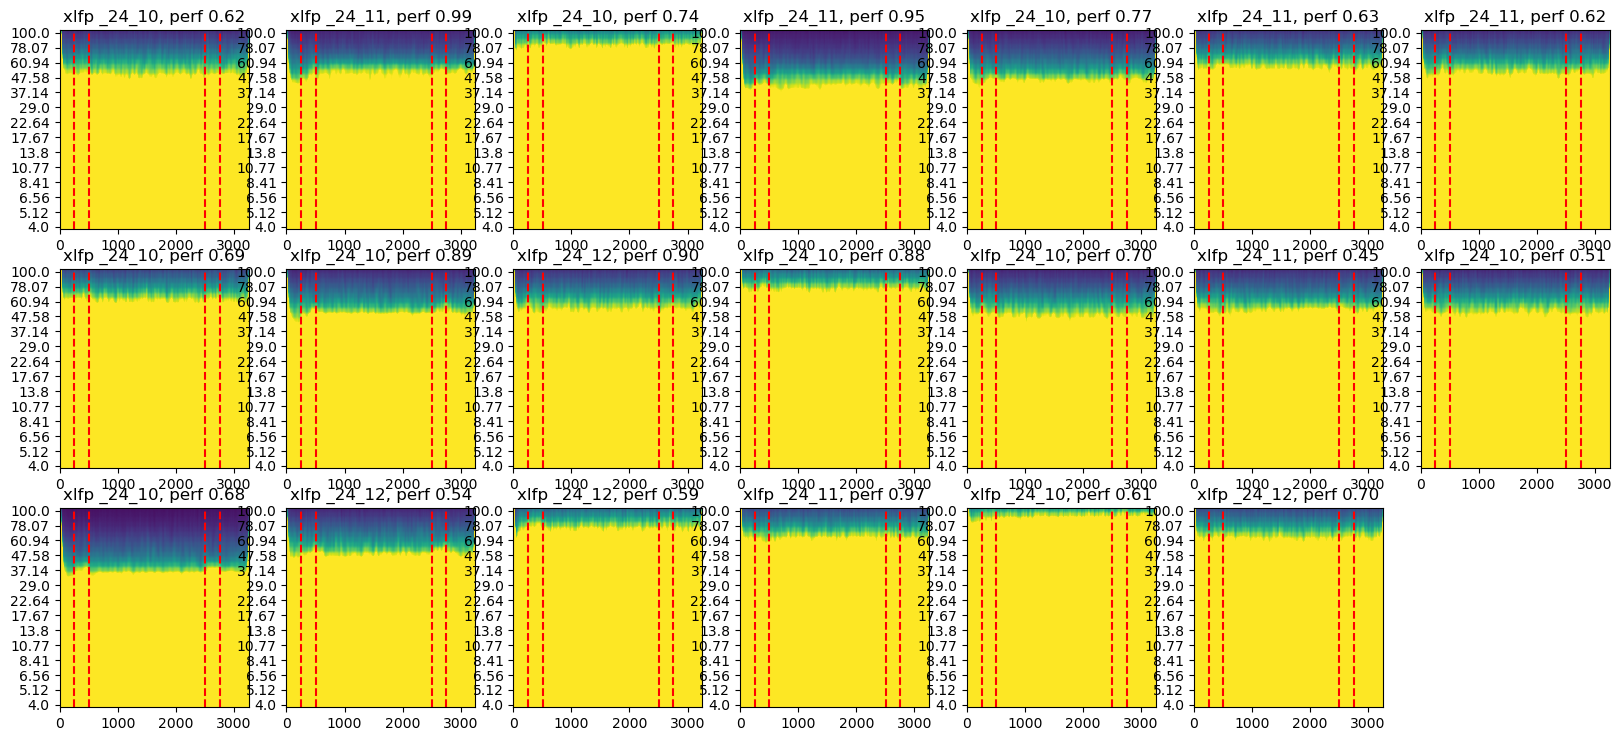

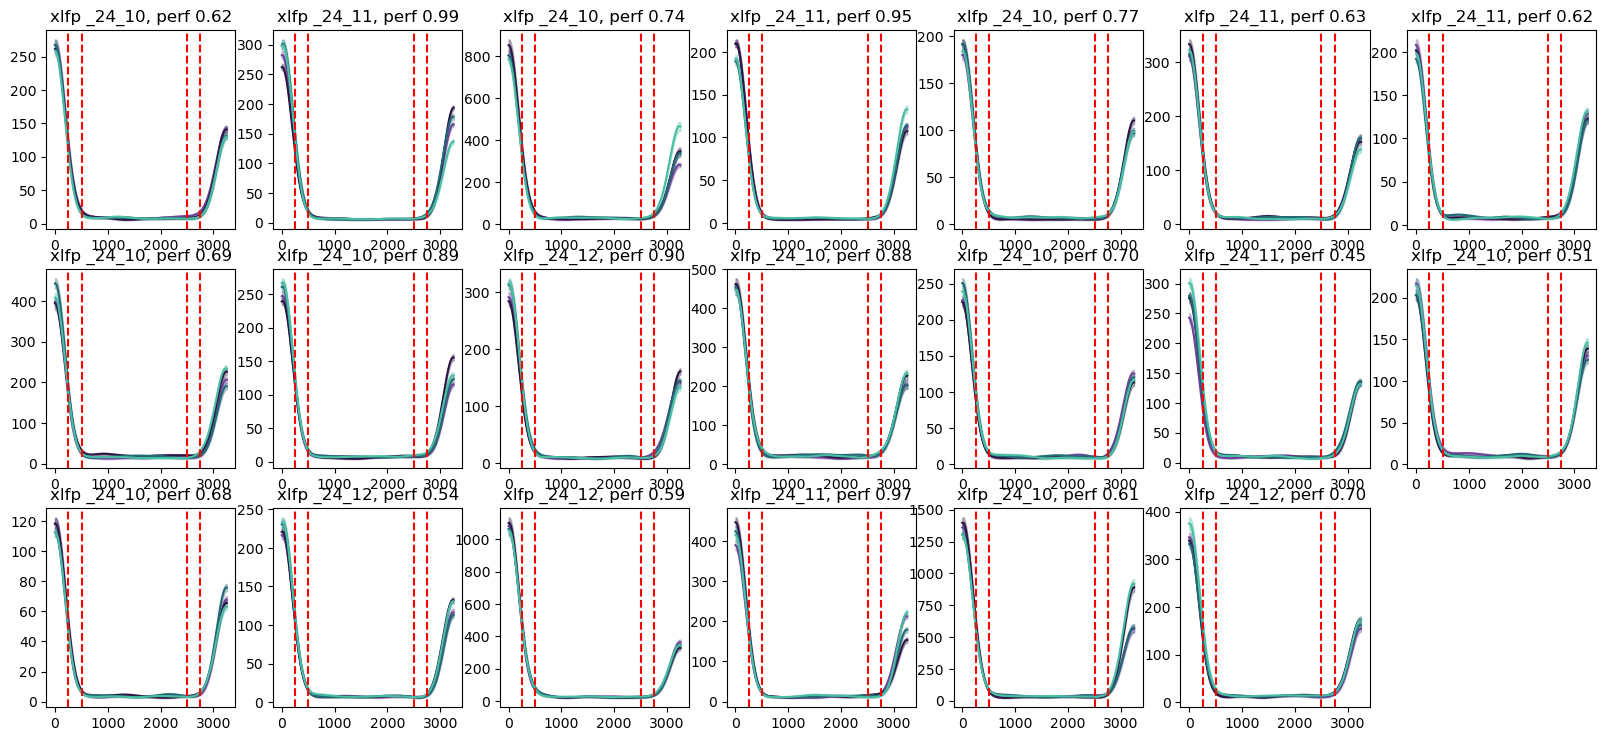

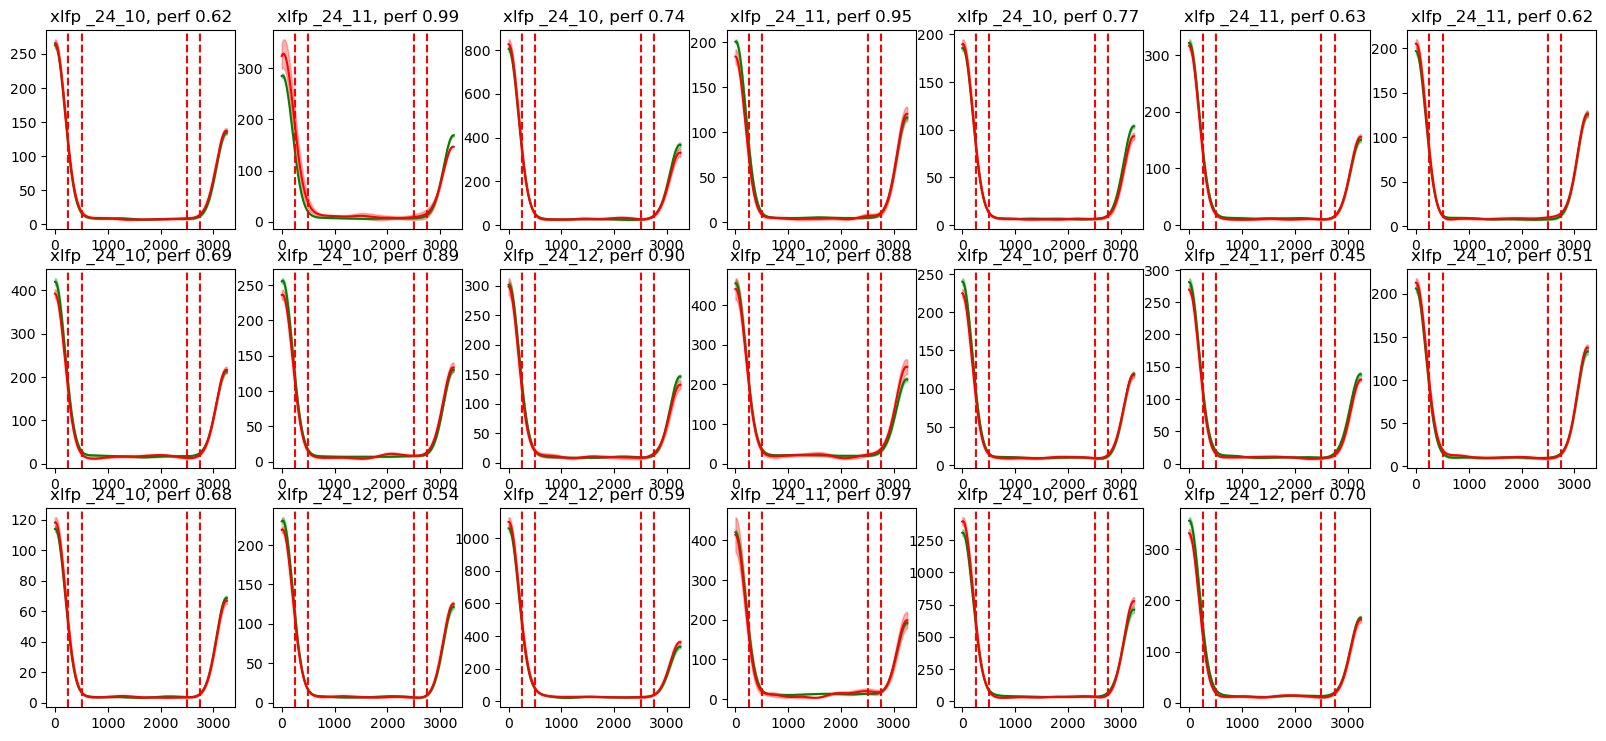

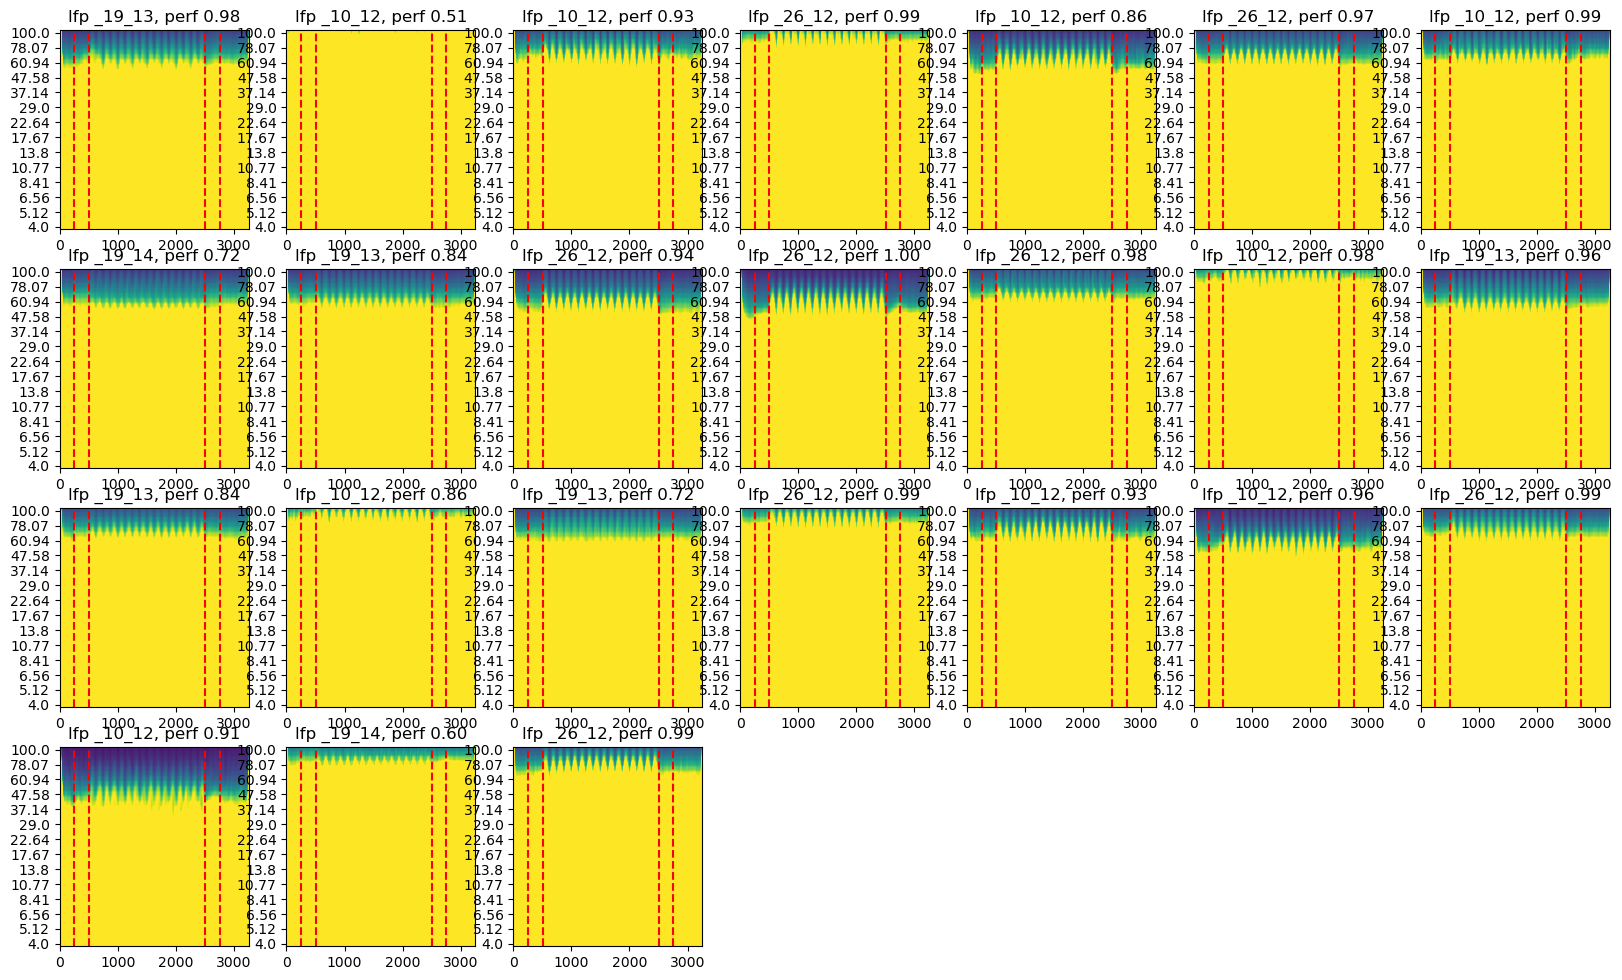

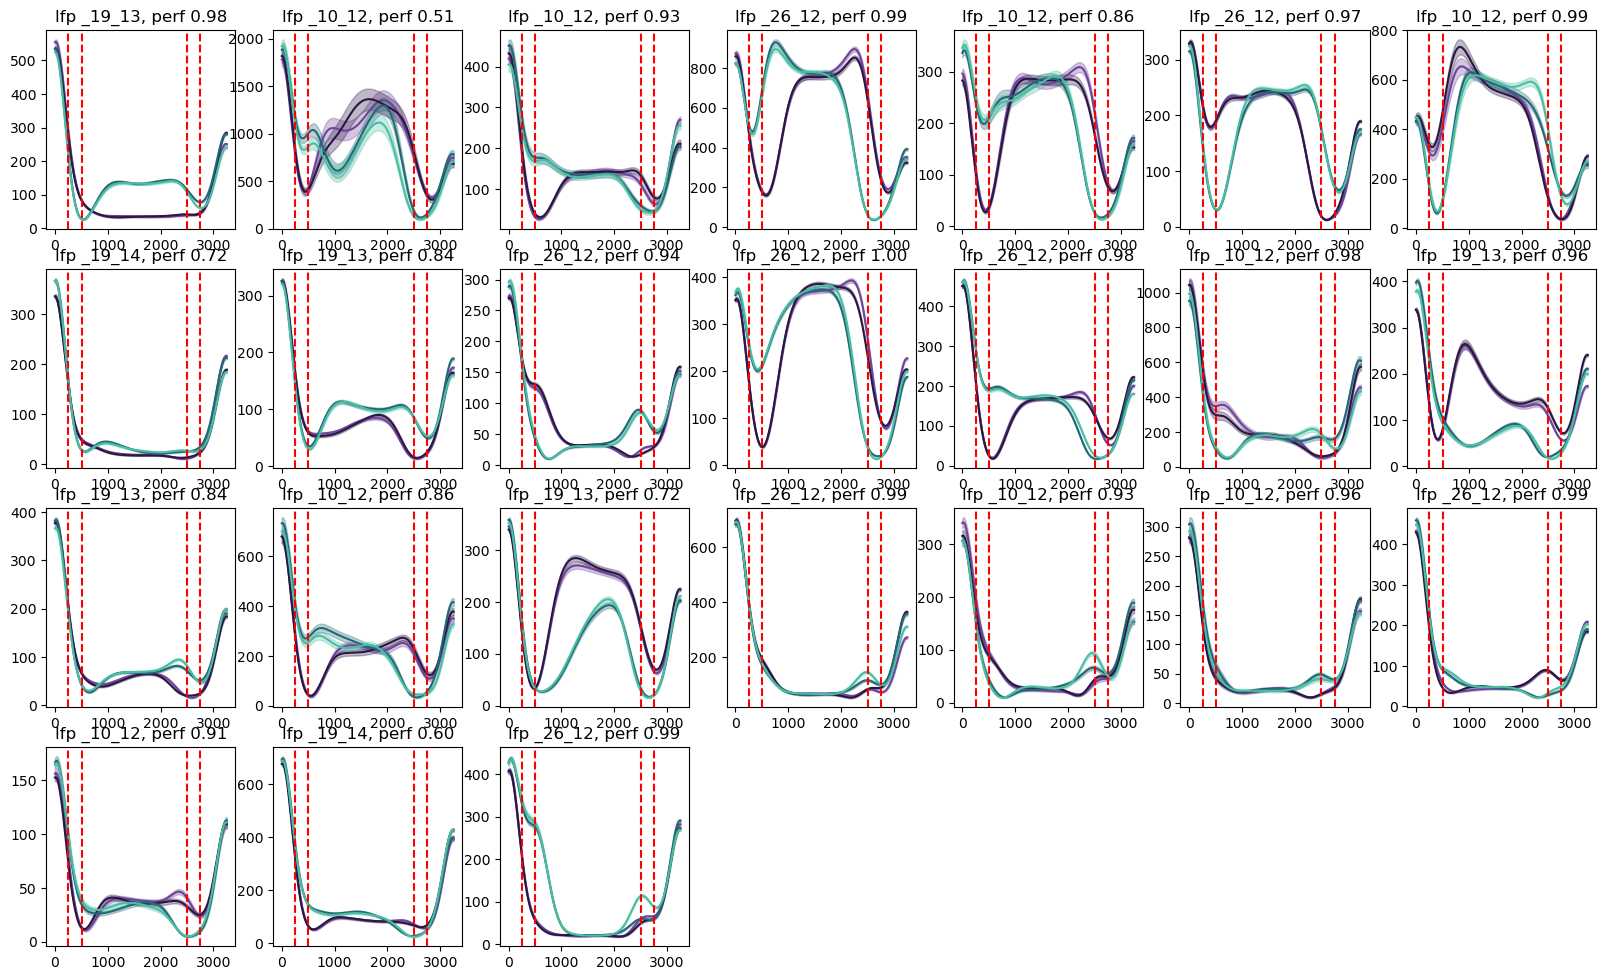

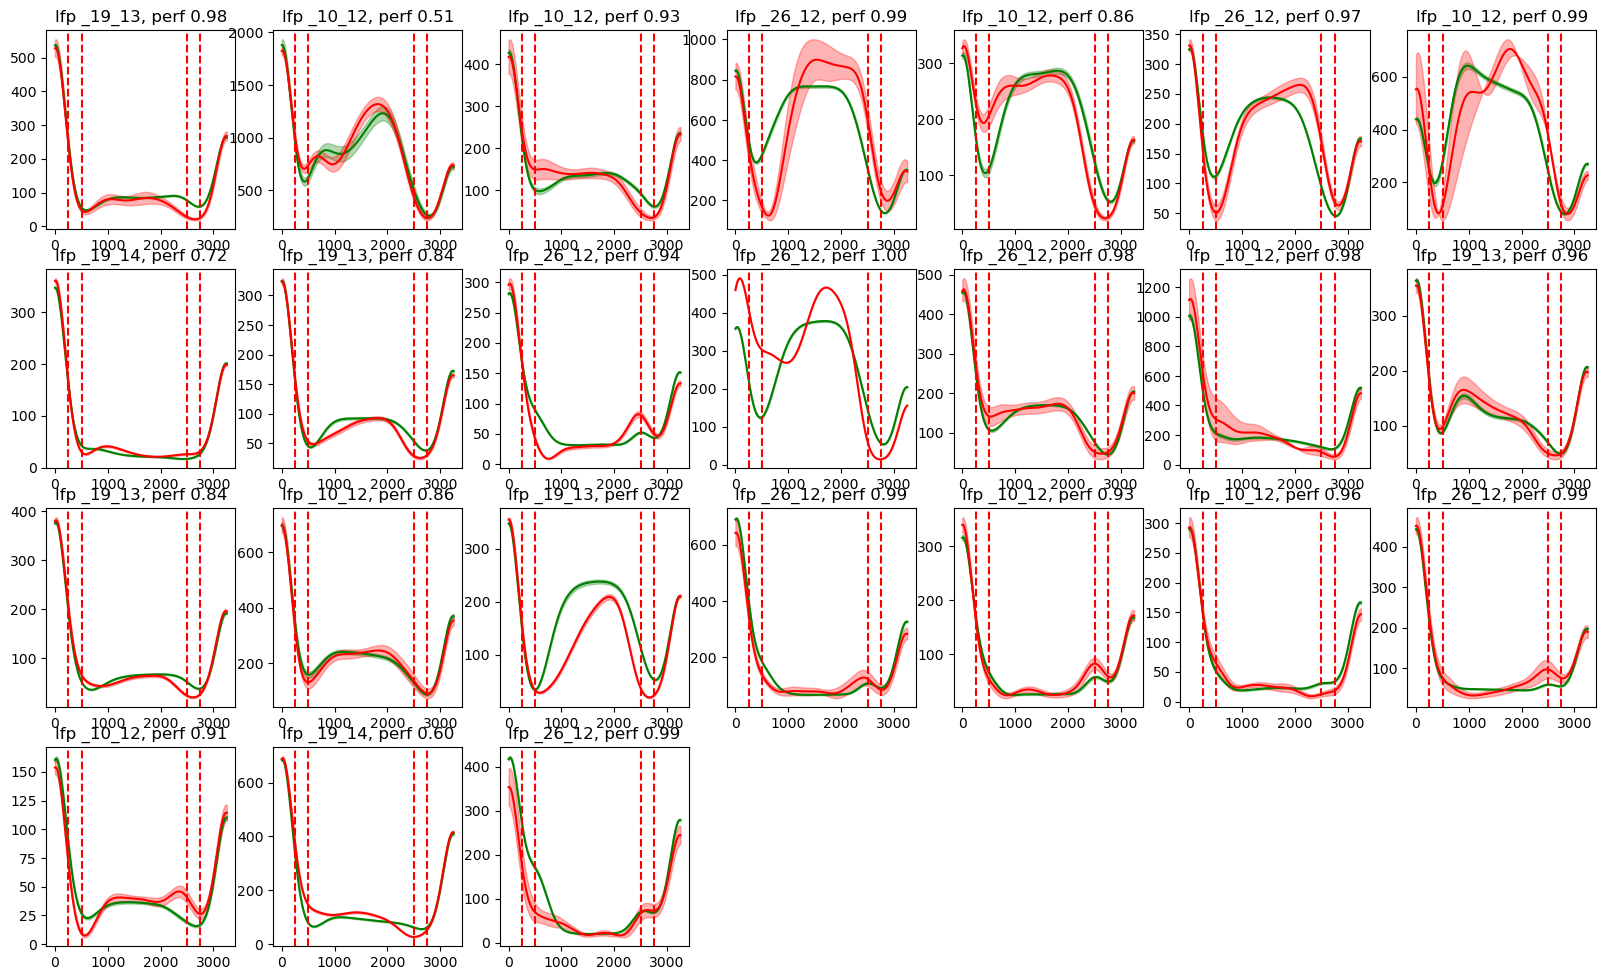

In [ ]:
# make plots: spect, bandpower by trial type, bandpower by correct/incorrect -- z-scoring at bandpower step

importlib.reload(lu)

model_lists = [jitter_dirs, theta4_dirs] #, lfp_alpha_model_list]
model_dirs = [all_jitter_models_dir, all_lfp_models_dir] #, lfp_model_dir]
model_list_names = ['xlfp', 'lfp'] #, 'lfp_alpha']
model_powers = [4, 4]
condn = 'delay400.'

for model_list, model_dir, model_list_name, model_power in zip(model_lists, model_dirs, model_list_names, model_powers):

    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')
    
    # create figure
    fig1 = plt.figure(figsize=(20, 15)) # spectrogram
    fig2 = plt.figure(figsize=(20, 15)) # band power, split by trial type
    fig3 = plt.figure(figsize=(20, 15)) # band power, split by correct/incorrect

    for model_name in model_list:
        # print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name + '/'
        
        # get neural and behavioral data
        lfp_data, _, _ = ld.load_neural_data(model_name, condn_phrase, 
                                             all_models_dir = model_dir, load_LFP=True)
        # lfp_data is time x neurons x trials
        lfp_data = np.nanmean(lfp_data, axis=1).T # avg across neurons, then transpose, trials x time
        trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, 
                                                     all_models_dir = model_dir,)
        times_fs, times_real, fs_dict = ld.get_times_dict('ds', condn_phrase, model_name = model_name,
                                                          all_models_dir = model_dir)
        
        # calculate spectrogram data for all trials
        n_freqs = 40
        n_trials = lfp_data.shape[0]
        
        trial_power, freqs, phase = lu.compute_lfp_power(lfp_data, int(fs_dict['ds']), freq_range = [4, 100], num_freqs = n_freqs, n_cycles=7)
        trial_powerband = lu.compute_bandpower(trial_power, freqs, settings=None, band=[model_power], zscore=False, baseline=[10, 50])

        # first plot spectrogram
        ax1 = fig1.add_subplot(5, 7, model_list.index(model_name)+1)
        ax1.imshow(np.mean(trial_power, axis=0), aspect='auto', origin='lower')#,
            #    vmin=0, vmax=1.2)
        ax1.set_yticks(np.arange(0, 40, 3), np.round(freqs[::3], 2))
        # ax1.colorbar(label='Power')
        ax1.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(trial_perfs)):.2f}')
        ax1.axvline(x=times_fs['stim1_on'], color='r', linestyle='--')
        ax1.axvline(x=times_fs['stim1_off'], color='r', linestyle='--')
        ax1.axvline(x=times_fs['stim2_on'], color='r', linestyle='--')
        ax1.axvline(x=times_fs['stim2_off'], color='r', linestyle='--')
        
        # then plot band power, split by trial type
        ax2 = fig2.add_subplot(5,7, model_list.index(model_name)+1)
        stims, colors = ld.get_trialtype_colors()
        trial_types, trial_idxs = np.unique(trial_labels, axis=0, return_inverse=True)
        for i, trial_type in enumerate(trial_types):
            trials_idx = (trial_idxs == i)
            powerband_mean = np.mean(trial_powerband[trials_idx, :], axis=0)
            powerband_sem = np.std(trial_powerband[trials_idx, :], axis=0) / np.sqrt(np.sum(trials_idx))
            ax2.plot(powerband_mean, color=colors[i])#, label=stims[i])
            ax2.fill_between(np.arange(times_fs['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color=colors[i], alpha=0.3)
        ax2.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(trial_perfs)):.2f}')
        ax2.axvline(x=times_fs['stim1_on'], color='r', linestyle='--')
        ax2.axvline(x=times_fs['stim1_off'], color='r', linestyle='--')
        ax2.axvline(x=times_fs['stim2_on'], color='r', linestyle='--')
        ax2.axvline(x=times_fs['stim2_off'], color='r', linestyle='--')
        
        # finally plot band power, split by correct/incorrect
        ax3 = fig3.add_subplot(5, 7, model_list.index(model_name)+1)
        correct_trials = (trial_perfs == 1)
        incorrect_trials = (trial_perfs == 0)
        powerband_mean = np.mean(trial_powerband[correct_trials, :], axis=0)
        powerband_sem = np.std(trial_powerband[correct_trials, :], axis=0) / np.sqrt(np.sum(correct_trials))
        ax3.plot(powerband_mean, color='g', label='correct')
        ax3.fill_between(np.arange(times_fs['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color='g', alpha=0.3)
        powerband_mean = np.mean(trial_powerband[incorrect_trials, :], axis=0)
        powerband_sem = np.std(trial_powerband[incorrect_trials, :], axis=0) / np.sqrt(np.sum(incorrect_trials))
        ax3.plot(powerband_mean, color='r', label='incorrect')
        ax3.fill_between(np.arange(times_fs['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color='r', alpha=0.3)
        ax3.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(trial_perfs)):.2f}')
        ax3.axvline(x=times_fs['stim1_on'], color='r', linestyle='--')
        ax3.axvline(x=times_fs['stim1_off'], color='r', linestyle='--')
        ax3.axvline(x=times_fs['stim2_on'], color='r', linestyle='--')
        ax3.axvline(x=times_fs['stim2_off'], color='r', linestyle='--')



In [6]:
# get avg bandpower during delay

importlib.reload(lu)

model_lists = [jitter_dirs, theta4_dirs] #, lfp_alpha_model_list]
model_dirs = [all_jitter_models_dir, all_lfp_models_dir] #, lfp_model_dir]
model_list_names = ['xlfp', 'lfp'] #, 'lfp_alpha']
model_powers = [4, 4]
condn = 'delay400.'

delay_bandpower = { 'xlfp': [], 'lfp': [] }

for model_list, model_dir, model_list_name, model_power in zip(model_lists, model_dirs, model_list_names, model_powers):

    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')

    for model_name in model_list:
        # print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name + '/'
        
        # get neural and behavioral data
        lfp_data, _, _ = ld.load_neural_data(model_name, condn_phrase, 
                                             all_models_dir = model_dir, load_LFP=True)
        # lfp_data is time x neurons x trials
        lfp_data = np.nanmean(lfp_data, axis=1).T # avg across neurons, then transpose, trials x time
        trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, 
                                                     all_models_dir = model_dir,)
        times_fs, times_real, fs_dict = ld.get_times_dict('ds', condn_phrase, model_name = model_name,
                                                          all_models_dir = model_dir)
        
        # calculate spectrogram data for all trials
        n_freqs = 40
        n_trials = lfp_data.shape[0]
        
        trial_power, freqs, phase = lu.compute_lfp_power(lfp_data, int(fs_dict['ds']), freq_range = [4, 100], num_freqs = n_freqs, n_cycles=7)
        trial_powerband = lu.compute_bandpower(trial_power, freqs, settings=None, band=[model_power], zscore=False, baseline=[10, 50])
        
        delay_idx = np.arange(int(times_fs['stim1_off']), int(times_fs['stim2_on']))
        avg_delay_power = np.mean(trial_powerband[:, delay_idx], axis=1) # [n_trials,]
        delay_bandpower[model_list_name].append(np.mean(avg_delay_power)) # 1 value, mean power during delay
    delay_bandpower[model_list_name] = np.array(delay_bandpower[model_list_name])
    print(f'{model_list_name} avg delay bandpower shape: {delay_bandpower[model_list_name].shape}')
        

Processing model type: xlfp, number of models: 20
xlfp avg delay bandpower shape: (20,)
Processing model type: lfp, number of models: 24
lfp avg delay bandpower shape: (24,)


Mann-Whitney U test: stat=8.000, p=0.000


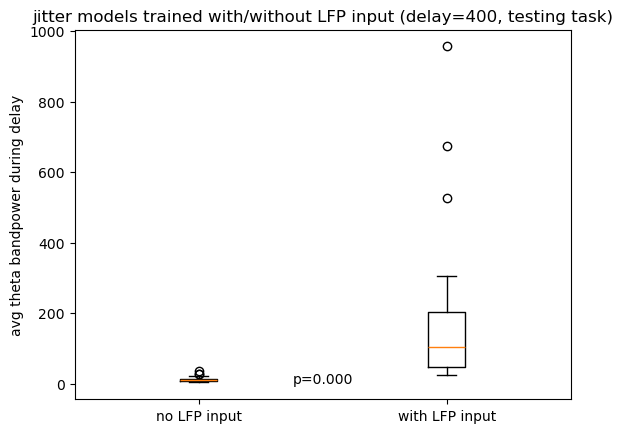

In [7]:
plt.figure()
plt.boxplot([delay_bandpower['xlfp'], 
             delay_bandpower['lfp']], 
            positions=[1, 2]) # mean across trials
plt.xticks([1, 2], ['no LFP input', 'with LFP input'])
plt.ylabel('avg theta bandpower during delay')
plt.title('jitter models trained with/without LFP input (delay=400, testing task)')
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(delay_bandpower['xlfp'], 
                       delay_bandpower['lfp'])
print('Mann-Whitney U test: stat=%.3f, p=%.3f' % (stat, p))
plt.text(1.5, 0.9, 'p=%.3f' % p, ha='center')
plt.show()


[0, 22, 7, 16, 11, 9, 2, 15, 14, 8, 13, 3, 18, 21, 6, 19, 23, 4, 20, 17]
Mann-Whitney U test: stat=8.000, p=0.000


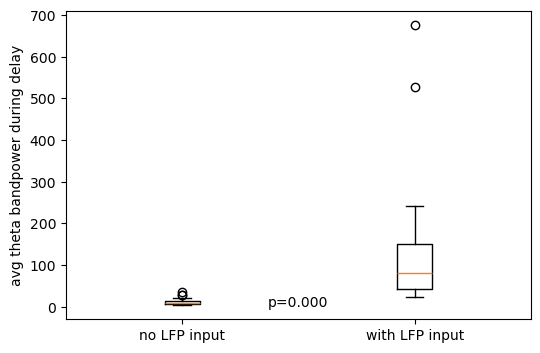

In [9]:
# for abstract — choose 20 for each

# np.random.seed(12)
# i_models = np.random.choice(len(delay_bandpower['xlfp']), 20, replace=False)
i_models = [ 0, 22,  7, 16, 11,  9,  2, 15, 14,  8, 13,  3, 18, 21,  6, 19, 23,  4, 20, 17]
print(i_models)

plt.figure(figsize=(6,4))
plt.boxplot([delay_bandpower['xlfp'], 
             delay_bandpower['lfp'][i_models]], 
            positions=[1, 2]) # mean across trials
plt.xticks([1, 2], ['no LFP input', 'with LFP input'])
plt.ylabel('avg theta bandpower during delay')
# plt.title('jitter models trained with/without LFP input (delay=400, testing task)')
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(delay_bandpower['xlfp'],
                       delay_bandpower['lfp'][i_models])
print('Mann-Whitney U test: stat=%.3f, p=%.3f' % (stat, p))
plt.text(1.5, 0.9, 'p=%.3f' % p, ha='center')

# save as eps
plt.savefig('SfN_model_spk_delaytheta_comparison.eps', format='eps', dpi=1000)

plt.show()


### for LFP inputs only to exc or inh populations

Processing model type: lfp, number of models: 24
Processing model type: lfp, number of models: 24


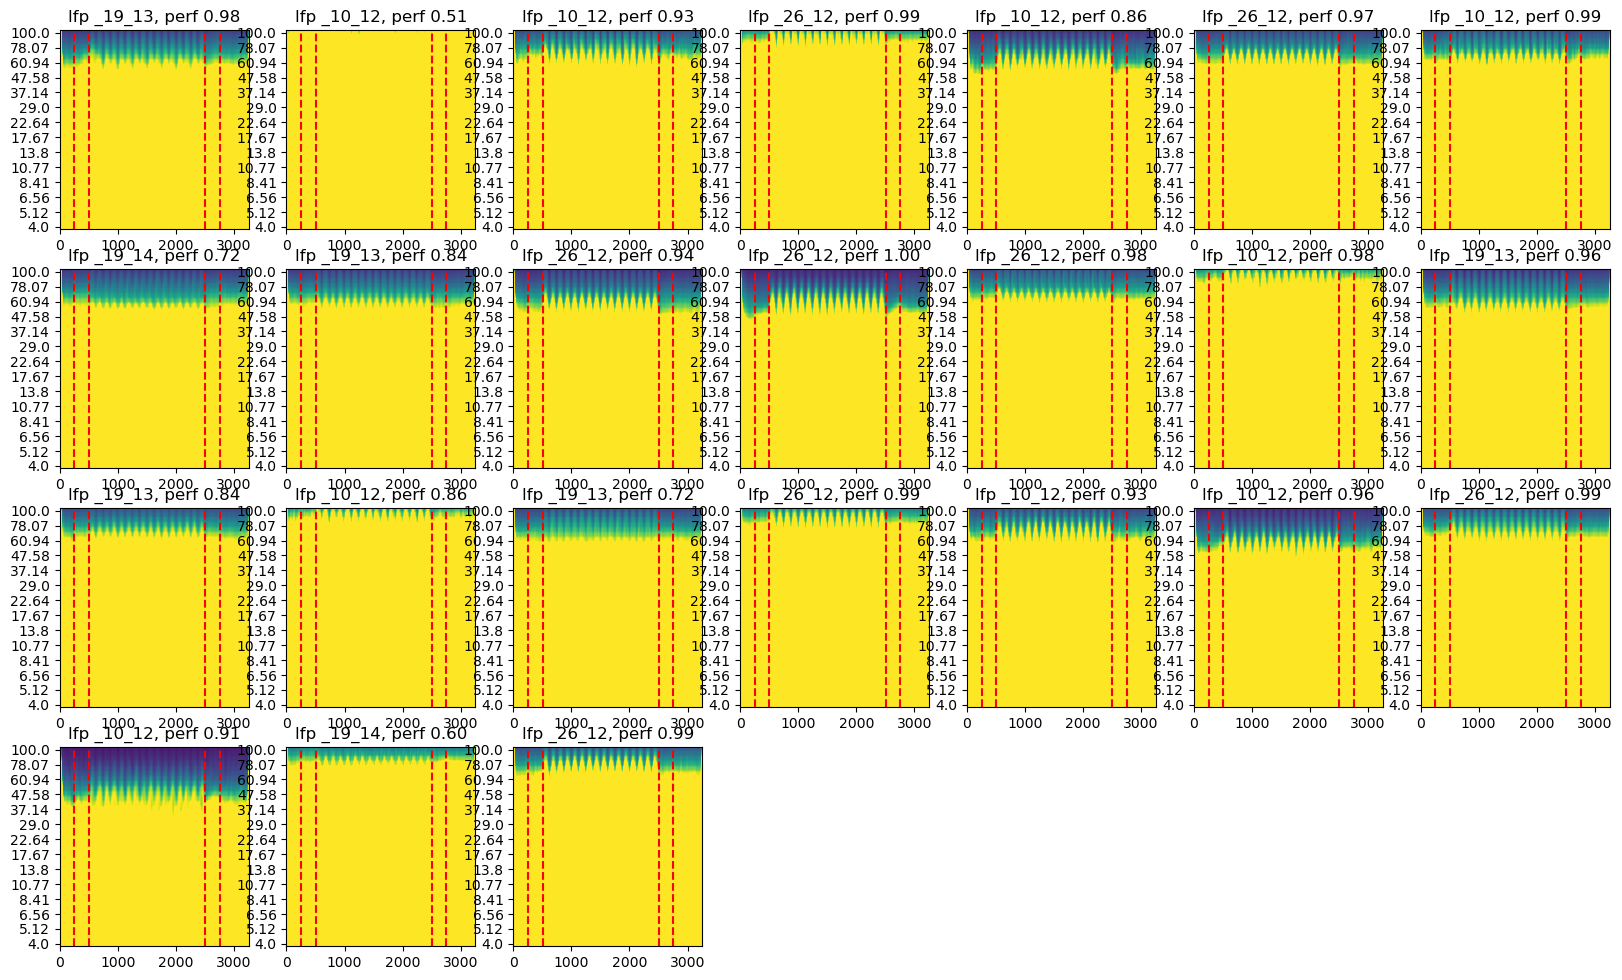

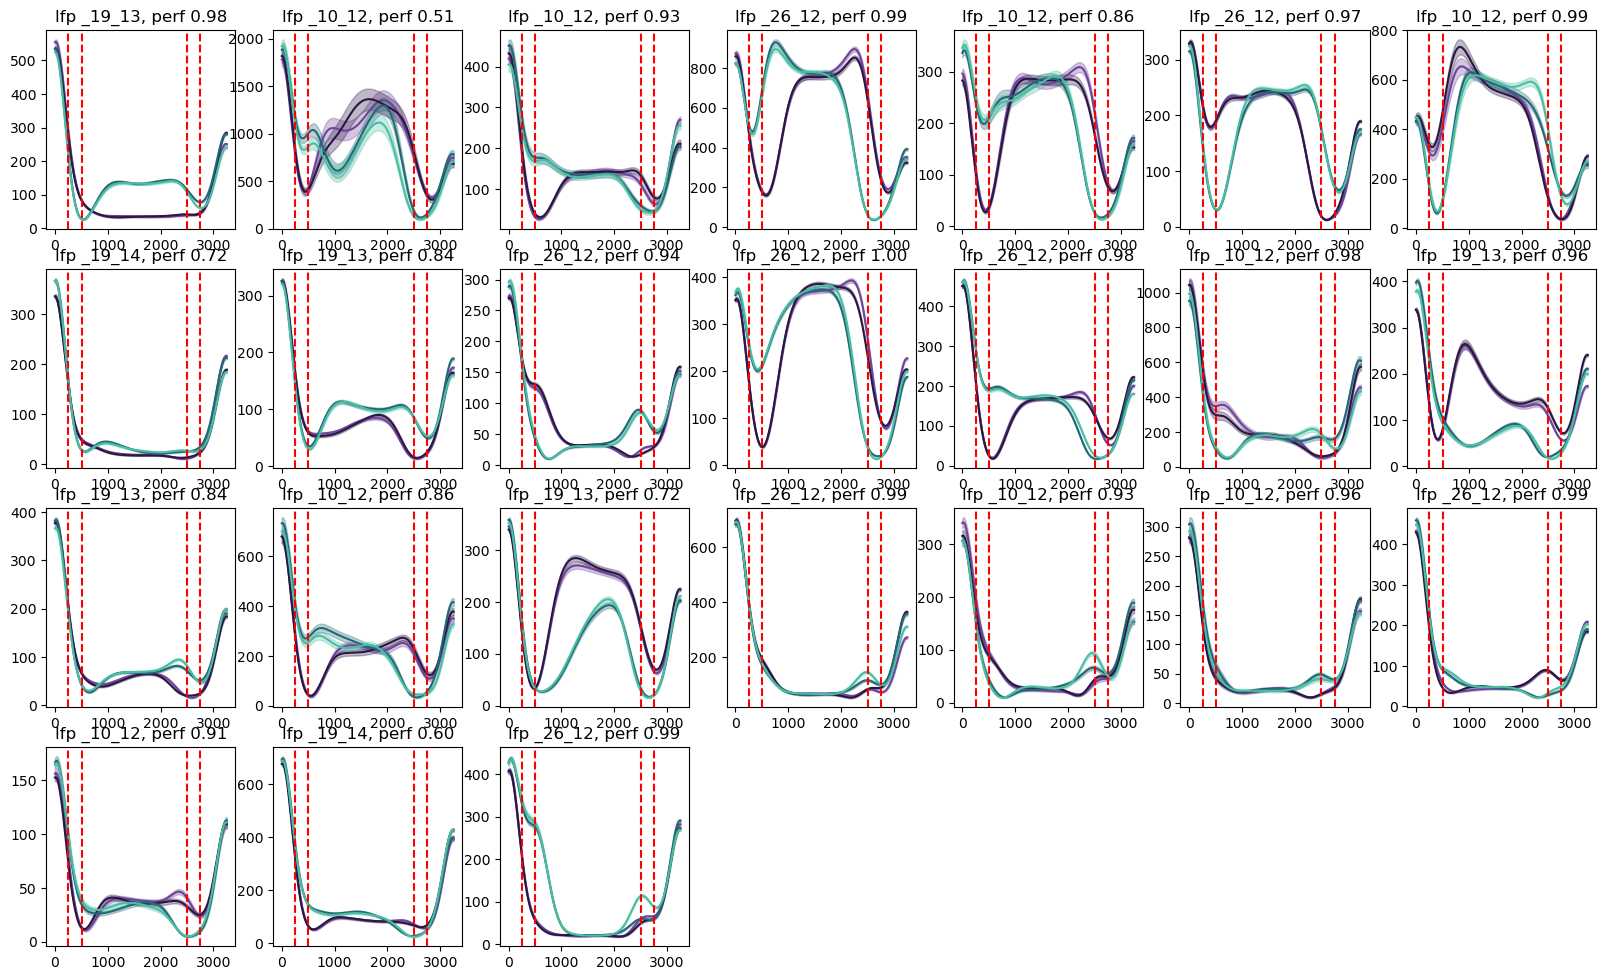

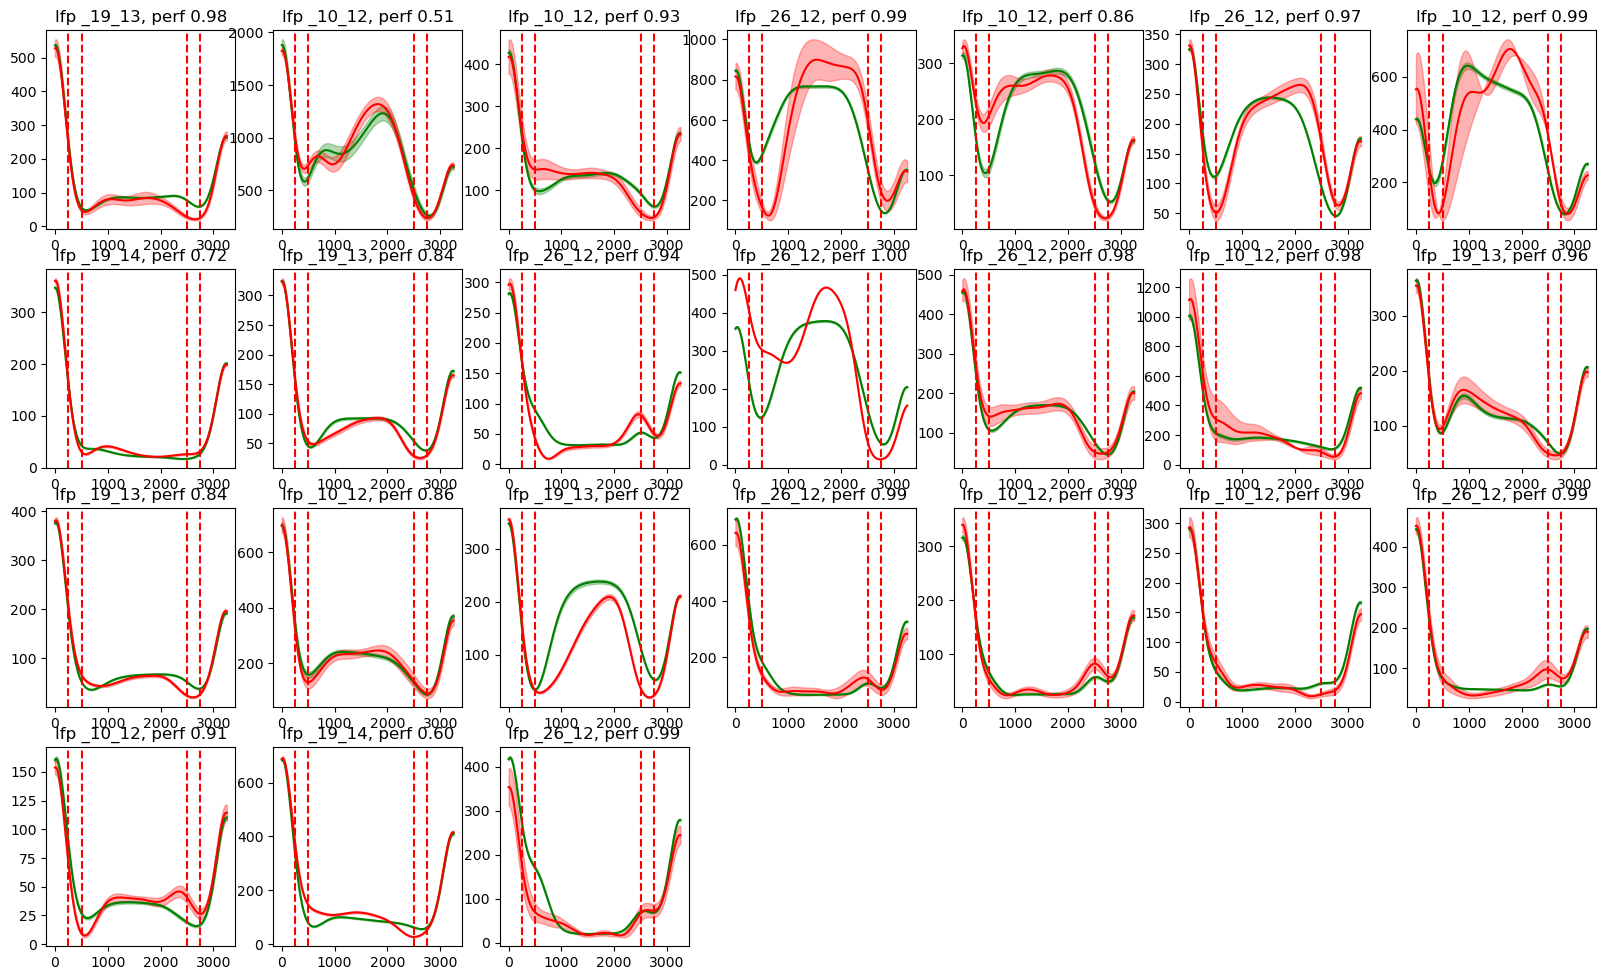

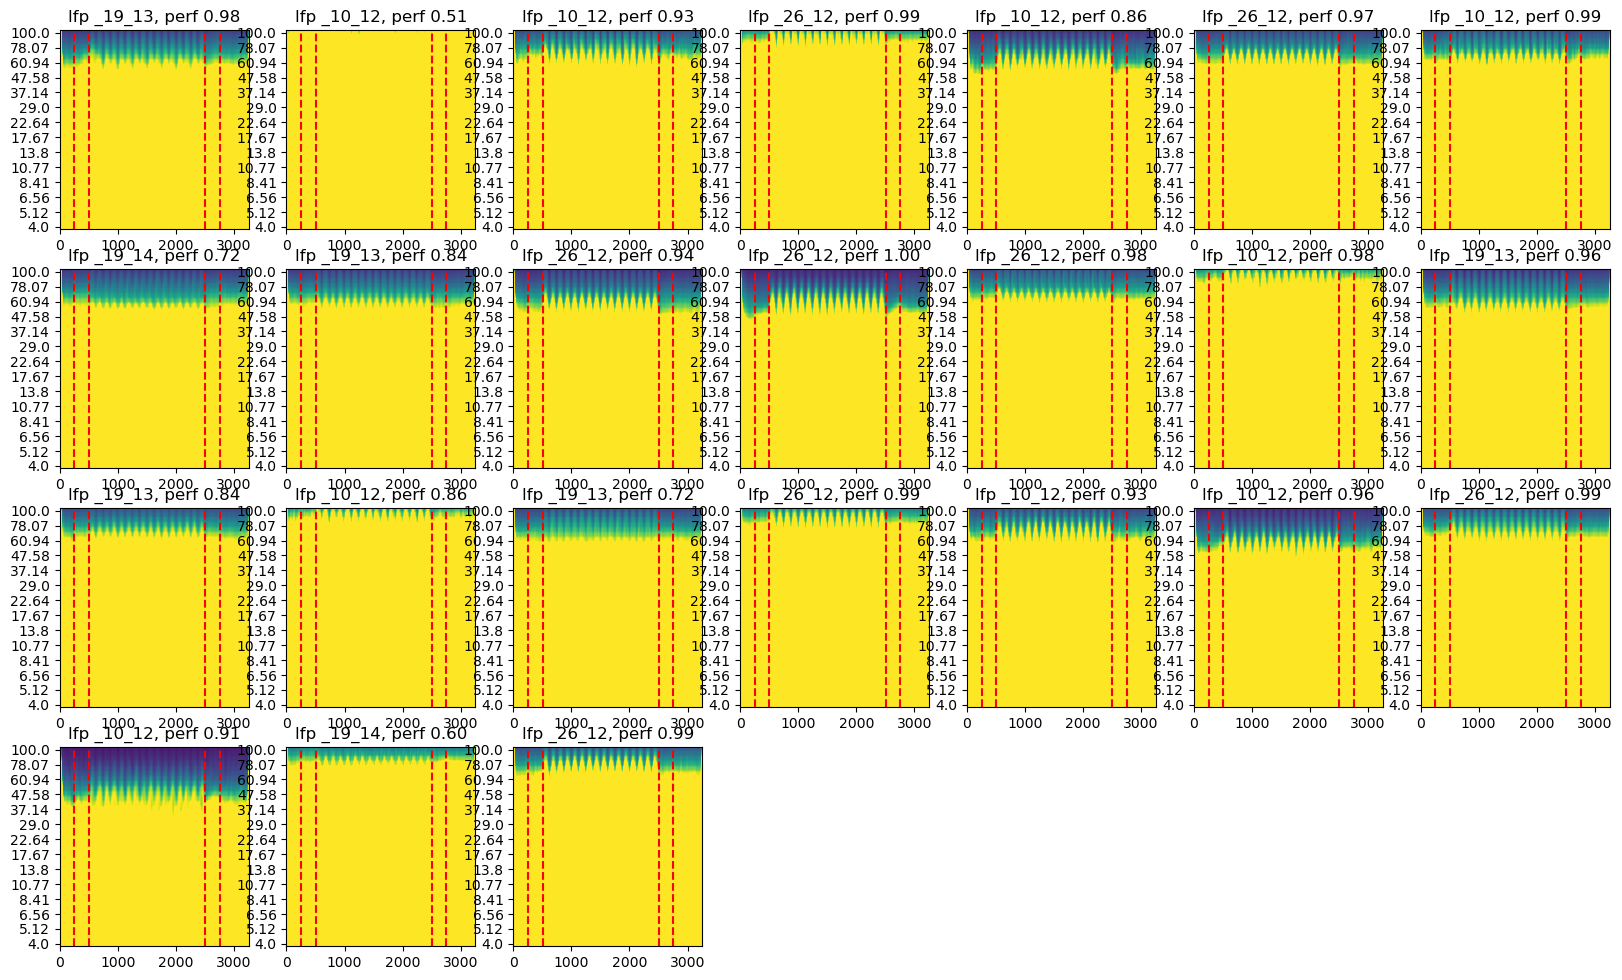

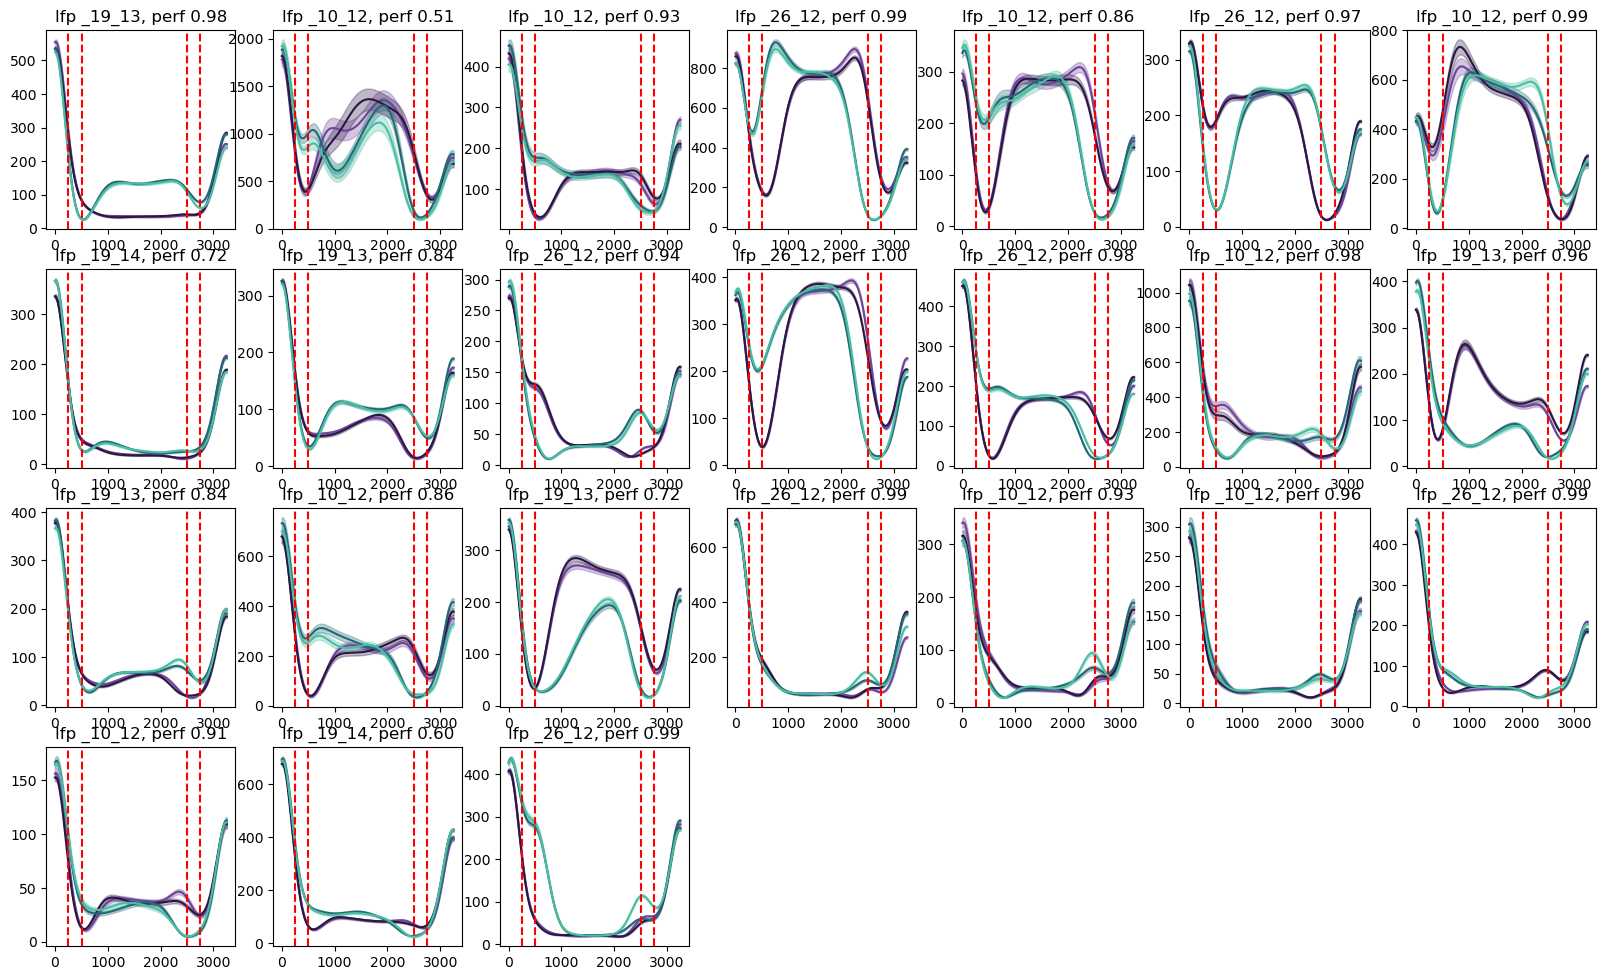

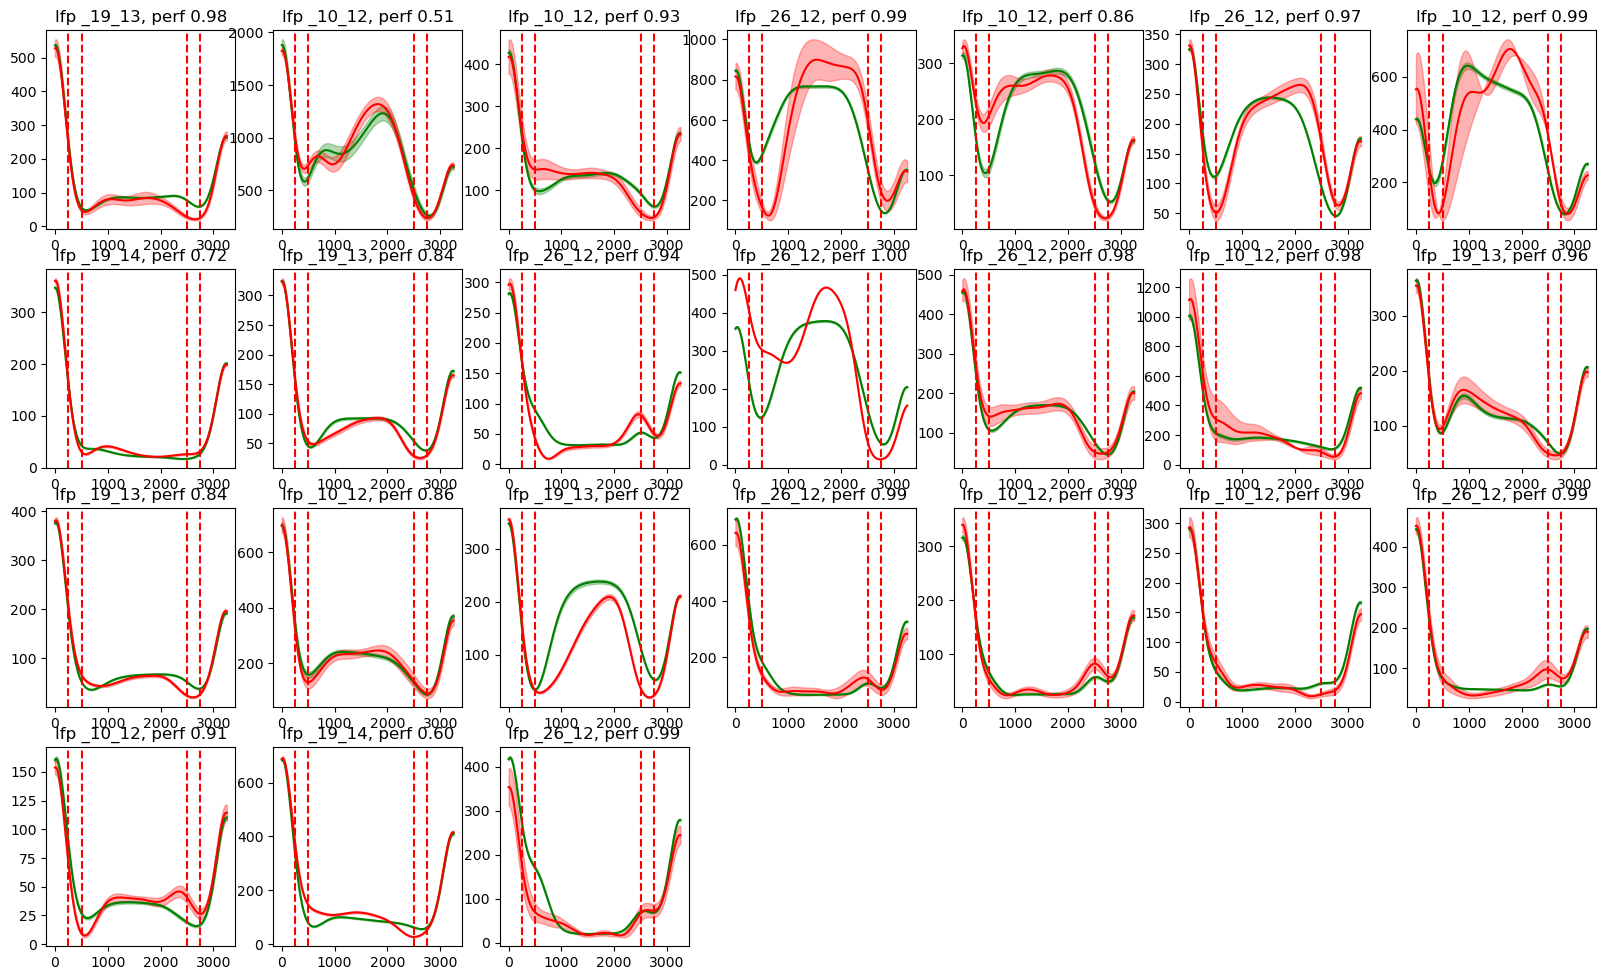

In [30]:
# make plots: spect, bandpower by trial type, bandpower by correct/incorrect -- not z-scoring at bandpower step

importlib.reload(lu)

model_list = theta4_dirs #, lfp_alpha_model_list]
model_dir = all_lfp_models_dir #, lfp_model_dir]
model_list_name = 'lfp' #, 'lfp_alpha']
model_power = 4
condns = ['delay400exconly', 'delay400inhonly']

for condn in condns:

    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')
    
    # create figure
    fig1 = plt.figure(figsize=(20, 15)) # spectrogram
    fig2 = plt.figure(figsize=(20, 15)) # band power, split by trial type
    fig3 = plt.figure(figsize=(20, 15)) # band power, split by correct/incorrect

    for model_name in model_list:
        # print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name + '/'
        
        # get neural and behavioral data
        lfp_data, _, _ = ld.load_neural_data(model_name, condn_phrase, 
                                            all_models_dir = model_dir, load_LFP=True)
        # lfp_data is time x neurons x trials
        lfp_data = np.nanmean(lfp_data, axis=1).T # avg across neurons, then transpose, trials x time
        trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, 
                                                    all_models_dir = model_dir,)
        times_fs, times_real, fs_dict = ld.get_times_dict('ds', condn_phrase, model_name = model_name,
                                                        all_models_dir = model_dir)
        
        # calculate spectrogram data for all trials
        n_freqs = 40
        n_trials = lfp_data.shape[0]
        
        trial_power, freqs, phase = lu.compute_lfp_power(lfp_data, int(fs_dict['ds']), freq_range = [4, 100], num_freqs = n_freqs, n_cycles=7)
        trial_powerband = lu.compute_bandpower(trial_power, freqs, settings=None, band=[model_power], zscore=False, baseline=[10, 50])
        
        # first plot spectrogram
        ax1 = fig1.add_subplot(5, 7, model_list.index(model_name)+1)
        ax1.imshow(np.mean(trial_power, axis=0), aspect='auto', origin='lower',
               vmin=0, vmax=1.2)
        ax1.set_yticks(np.arange(0, 40, 3), np.round(freqs[::3], 2))
        # ax1.colorbar(label='Power')
        ax1.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(trial_perfs)):.2f}')
        ax1.axvline(x=times_fs['stim1_on'], color='r', linestyle='--')
        ax1.axvline(x=times_fs['stim1_off'], color='r', linestyle='--')
        ax1.axvline(x=times_fs['stim2_on'], color='r', linestyle='--')
        ax1.axvline(x=times_fs['stim2_off'], color='r', linestyle='--')
        
        # then plot band power, split by trial type
        ax2 = fig2.add_subplot(5,7, model_list.index(model_name)+1)
        stims, colors = ld.get_trialtype_colors()
        trial_types, trial_idxs = np.unique(np.array(trial_labels), axis=0, return_inverse=True)
        for i, trial_type in enumerate(trial_types):
            trials_idx = (trial_idxs == i)
            powerband_mean = np.mean(trial_powerband[trials_idx, :], axis=0)
            powerband_sem = np.std(trial_powerband[trials_idx, :], axis=0) / np.sqrt(np.sum(trials_idx))
            ax2.plot(powerband_mean, color=colors[i])#, label=stims[i])
            ax2.fill_between(np.arange(times_fs['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color=colors[i], alpha=0.3)
        ax2.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(trial_perfs)):.2f}')
        ax2.axvline(x=times_fs['stim1_on'], color='r', linestyle='--')
        ax2.axvline(x=times_fs['stim1_off'], color='r', linestyle='--')
        ax2.axvline(x=times_fs['stim2_on'], color='r', linestyle='--')
        ax2.axvline(x=times_fs['stim2_off'], color='r', linestyle='--')
        
        # finally plot band power, split by correct/incorrect
        ax3 = fig3.add_subplot(5, 7, model_list.index(model_name)+1)
        correct_trials = (np.array(trial_perfs) == 1)
        incorrect_trials = (np.array(trial_perfs) == 0)
        powerband_mean = np.mean(trial_powerband[correct_trials, :], axis=0)
        powerband_sem = np.std(trial_powerband[correct_trials, :], axis=0) / np.sqrt(np.sum(correct_trials))
        ax3.plot(powerband_mean, color='g', label='correct')
        ax3.fill_between(np.arange(times_fs['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color='g', alpha=0.3)
        powerband_mean = np.mean(trial_powerband[incorrect_trials, :], axis=0)
        powerband_sem = np.std(trial_powerband[incorrect_trials, :], axis=0) / np.sqrt(np.sum(incorrect_trials))
        ax3.plot(powerband_mean, color='r', label='incorrect')
        ax3.fill_between(np.arange(times_fs['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color='r', alpha=0.3)
        ax3.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(trial_perfs)):.2f}')
        ax3.axvline(x=times_fs['stim1_on'], color='r', linestyle='--')
        ax3.axvline(x=times_fs['stim1_off'], color='r', linestyle='--')
        ax3.axvline(x=times_fs['stim2_on'], color='r', linestyle='--')
        ax3.axvline(x=times_fs['stim2_off'], color='r', linestyle='--')


In [6]:
# get avg bandpower during delay

importlib.reload(lu)

model_list = theta4_dirs #, lfp_alpha_model_list]
model_dir = all_lfp_models_dir #, lfp_model_dir]
model_list_names = ['all', 'exc0', 'inh0'] #, 'lfp_alpha']
model_power = 4
condns = ['delay400.','delay400inhonly', 'delay400exconly']

delay_bandpower = {'all': [], 'exc0': [], 'inh0': [] }

for i, condn_phrase in enumerate(condns):

    print(f'Processing model type: {model_list_names[i]}, number of models: {len(model_list)}')

    for model_name in model_list:
        # print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name + '/'
        
        # get neural and behavioral data
        lfp_data, _, _ = ld.load_neural_data(model_name, condn_phrase, 
                                            all_models_dir = model_dir, load_LFP=True)
        # lfp_data is time x neurons x trials
        lfp_data = np.nanmean(lfp_data, axis=1).T # avg across neurons, then transpose, trials x time
        trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, 
                                                    all_models_dir = model_dir,)
        times_fs, times_real, fs_dict = ld.get_times_dict('ds', condn_phrase, model_name = model_name,
                                                        all_models_dir = model_dir)
        
        # calculate spectrogram data for all trials
        n_freqs = 40
        n_trials = lfp_data.shape[0]
        
        trial_power, freqs, phase = lu.compute_lfp_power(lfp_data, int(fs_dict['ds']), freq_range = [4, 100], num_freqs = n_freqs, n_cycles=7)
        trial_powerband = lu.compute_bandpower(trial_power, freqs, settings=None, 
                                               band=[model_power], zscore=False, baseline=[10, 50])
        
        delay_idx = np.arange(int(times_fs['stim1_off']), int(times_fs['stim2_on']))
        avg_delay_power = np.mean(trial_powerband[:, delay_idx], axis=1) # [n_trials,]
        delay_bandpower[model_list_names[i]].append(np.mean(avg_delay_power)) # 1 value, mean power during delay
    delay_bandpower[model_list_names[i]] = np.array(delay_bandpower[model_list_names[i]])
    print(f'{model_list_names[i]} avg delay bandpower shape: {delay_bandpower[model_list_names[i]].shape}')
        

Processing model type: all, number of models: 24
all avg delay bandpower shape: (24,)
Processing model type: exc0, number of models: 24
exc0 avg delay bandpower shape: (24,)
Processing model type: inh0, number of models: 24
inh0 avg delay bandpower shape: (24,)


Mann-Whitney U test: stat=294.000, p=0.910
Mann-Whitney U test: stat=532.000, p=0.000
Mann-Whitney U test: stat=537.000, p=0.000


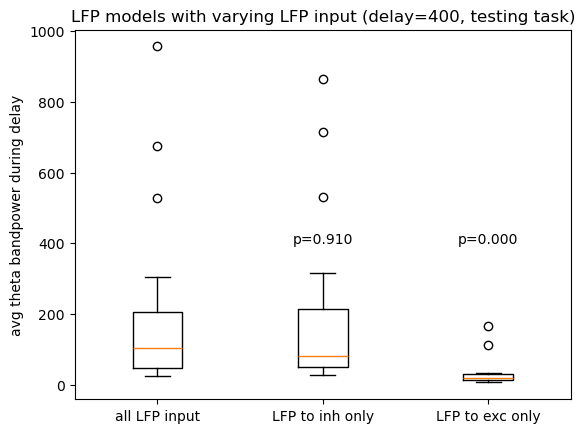

In [10]:
plt.figure()
plt.boxplot([delay_bandpower['all'],
             delay_bandpower['exc0'], 
             delay_bandpower['inh0']], 
            positions=[1, 2, 3]) # mean across trials
plt.xticks([1, 2, 3], ['all LFP input', 'LFP to inh only', 'LFP to exc only'])
plt.ylabel('avg theta bandpower during delay')
plt.title('LFP models with varying LFP input (delay=400, testing task)')
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(delay_bandpower['all'], 
                       delay_bandpower['exc0'])
print('Mann-Whitney U test: stat=%.3f, p=%.3f' % (stat, p))
plt.text(2, 400, 'p=%.3f' % p, ha='center')
stat, p = mannwhitneyu(delay_bandpower['all'], 
                       delay_bandpower['inh0'])
print('Mann-Whitney U test: stat=%.3f, p=%.3f' % (stat, p))
plt.text(3, 400, 'p=%.3f' % p, ha='center')
stat, p = mannwhitneyu(delay_bandpower['exc0'],
                       delay_bandpower['inh0'])
print('Mann-Whitney U test: stat=%.3f, p=%.3f' % (stat, p))
# plt.text(2, 0.7, 'p=%.3f' % p, ha='center')
plt.show()


[0, 22, 7, 16, 11, 9, 2, 15, 14, 8, 13, 3, 18, 21, 6, 19, 23, 4, 20, 17]
Mann-Whitney U test: stat=210.000, p=0.797
Mann-Whitney U test: stat=384.000, p=0.000
Mann-Whitney U test: stat=391.000, p=0.000


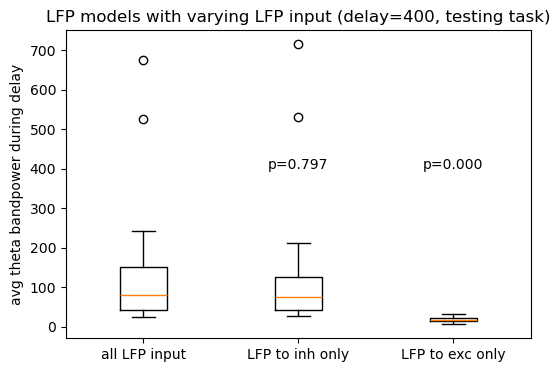

In [11]:
# for abstract — choose 20 for each

i_models = [ 0, 22,  7, 16, 11,  9,  2, 15, 14,  8, 13,  3, 18, 21,  6, 19, 23,  4, 20, 17]
print(i_models)

plt.figure(figsize=(6,4))
plt.boxplot([delay_bandpower['all'][i_models], 
             delay_bandpower['exc0'][i_models],
             delay_bandpower['inh0'][i_models]],
            positions=[1, 2, 3]) # mean across trials
plt.xticks([1, 2, 3], ['all LFP input', 'LFP to inh only', 'LFP to exc only'])
plt.ylabel('avg theta bandpower during delay')
plt.title('LFP models with varying LFP input (delay=400, testing task)')
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(delay_bandpower['all'][i_models], 
                       delay_bandpower['exc0'][i_models])
print('Mann-Whitney U test: stat=%.3f, p=%.3f' % (stat, p))
plt.text(2, 400, 'p=%.3f' % p, ha='center')
stat, p = mannwhitneyu(delay_bandpower['all'][i_models], 
                       delay_bandpower['inh0'][i_models])
print('Mann-Whitney U test: stat=%.3f, p=%.3f' % (stat, p))
plt.text(3, 400, 'p=%.3f' % p, ha='center')
stat, p = mannwhitneyu(delay_bandpower['exc0'][i_models], 
                       delay_bandpower['inh0'][i_models])
print('Mann-Whitney U test: stat=%.3f, p=%.3f' % (stat, p))
# plt.text(2, 0.7, 'p=%.3f' % p, ha='center')
plt.show()
